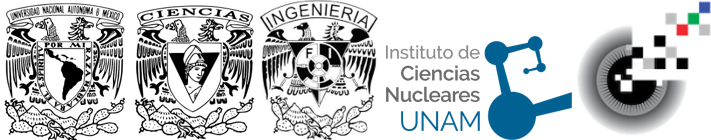

---

$$\Huge \textbf{5ª Escuela de Cómputo Cuántico}$$

$$\huge \text{Data Re-uploading Quantum Neural Networks}$$

# Autor: **Sebastián González Juárez**

### Día 5: **Agosto 7, 2026.**

---

# **Introducción**

<p align="justify" style="text-align: justify; width: 100%;">
Las <b>Redes Neuronales Cuánticas (Quantum Neural Networks, QNNs)</b> son modelos de aprendizaje automático que emplean circuitos cuánticos para resolver tareas como clasificación y regresión.
</p>

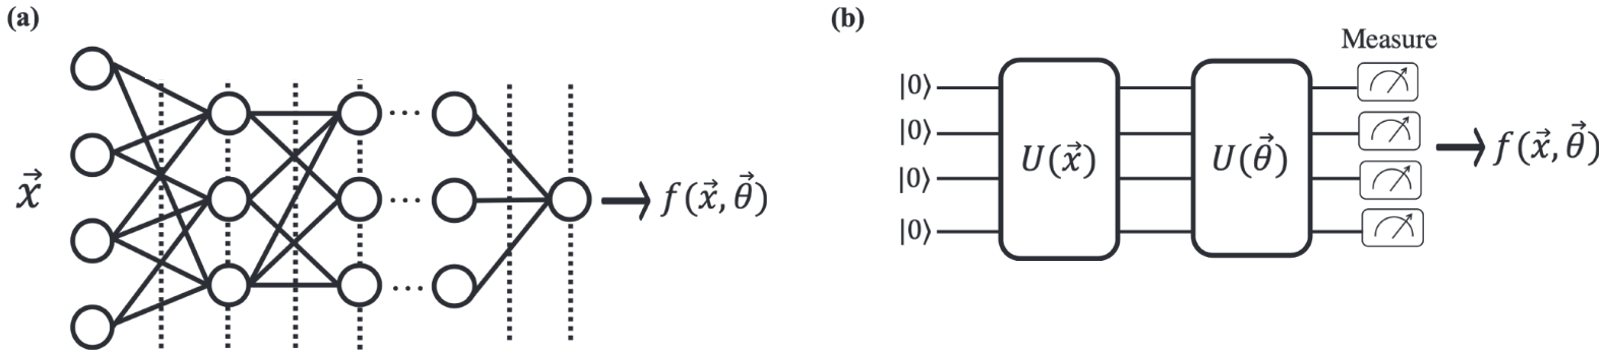

<p align="center">
  <small><b>Figura 1.</b> Comparación entre <b>(a)</b> una red neuronal clásica y <b>(b)</b> una red neuronal cuántica basada en un circuito cuántico variacional. <i>Tomado de [Fig. 1].</i></small>
</p>

<p align="justify" style="text-align: justify; width: 100%;">

El aprendizaje de una red neuronal se basa en:

</p>

<ul>
  <li><b>Predicción:</b> el modelo genera una salida a partir de los datos de entrada.</li>
  <li><b>Función de costo:</b> cuantifica el error entre la predicción y la etiqueta real.</li>
  <li><b>Optimizador:</b> actualiza los parámetros para minimizar la función de costo.</li>
</ul>

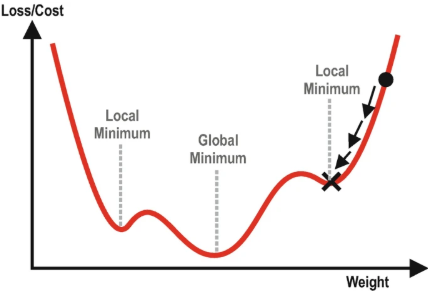

<p align="center">
  <small><b>Figura 2.</b> Función de pérdida con mínimos locales y un mínimo global durante el proceso de optimización. <i>Tomado de [Fig. 2].</i></small>
</p>

<p align="justify" style="text-align: justify; width: 100%;">
En este notebook se presentan dos formulaciones ampliamente utilizadas para la construcción de Redes Neuronales Cuánticas: los <b>Variational Quantum Classifiers (VQCs)</b> y las <b>Data Re-uploading Quantum Neural Networks (DRQNNs).
</b>

<p align="justify" style="text-align: justify; width: 100%;">
Además, se presenta una <b>extensión escalable</b> de las <b>DRQNNs</b> hacia múltiples qubits mediante una <b>construcción progresiva por bloques</b>, donde cada bloque incorpora un nuevo qubit reutilizando los parámetros previamente entrenados.
</p>

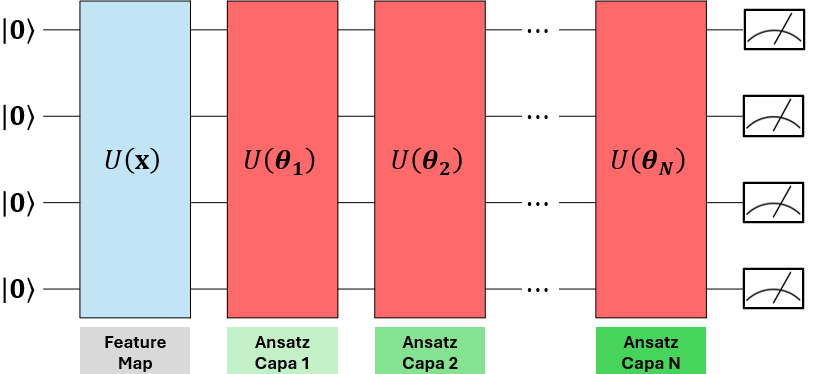

<p align="center">
  <small><b>Figura 3.</b> Variational Quantum Classifier (VQC).</i></small>
</p>

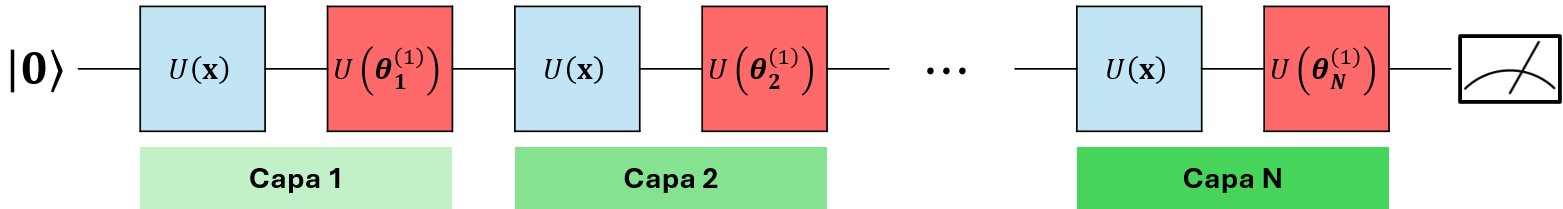

<p align="center">
  <small><b>Figura 4.</b> Data Re-uploading Quantum Neural Network (DRQNN).</i></small>
</p>

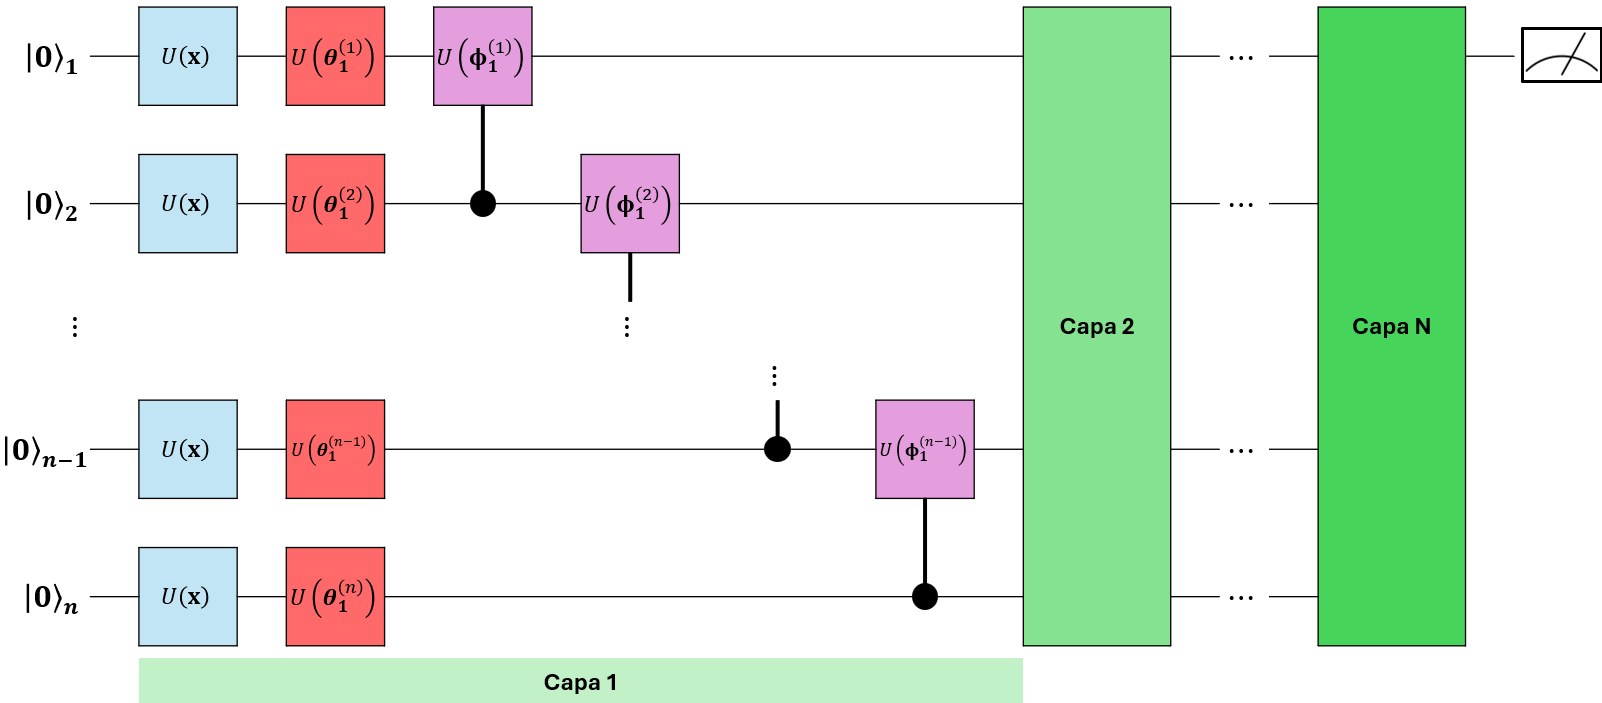

<p align="center">
  <small><b>Figura 5.</b> Extensión escalable de una DRQNN.</i></small>
</p>

<p align="justify" style="text-align: justify; width: 100%;">
A lo largo del notebook se desarrollarán estas arquitecturas mediante <b>PennyLane</b> y <b>PyTorch</b>, utilizando el conjunto de datos <b>Iris</b> como ejemplo de aplicación.
</p>

In [ ]:
!pip install -q pennylane

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pennylane as qml
from pennylane import numpy as pnp
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn

SEMILLA = 42

np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

In [ ]:
print(f"PennyLane: {qml.__version__}")

PennyLane: 0.45.1


## **Conjunto de datos Iris**

<p align="justify" style="text-align: justify; width: 100%;">
El conjunto de datos <b>Iris</b> contiene mediciones de <b>150 flores</b> pertenecientes a <b>tres especies</b>:
</p>

<ul>
  <li><i>Iris setosa</i></li>
  <li><i>Iris versicolor</i></li>
  <li><i>Iris virginica</i></li>
</ul>

<p align="justify" style="text-align: justify; width: 100%;">
Cada muestra está descrita por <b>cuatro características</b>:
</p>

<ul>
  <li><b>Longitud del sépalo</b> (<i>Sepal Length</i>)</li>
  <li><b>Ancho del sépalo</b> (<i>Sepal Width</i>)</li>
  <li><b>Longitud del pétalo</b> (<i>Petal Length</i>)</li>
  <li><b>Ancho del pétalo</b> (<i>Petal Width</i>)</li>
</ul>

<p align="justify" style="text-align: justify; width: 100%;">
<b>Objetivo:</b> identificar la especie de la flor a partir de estas mediciones.
</p>

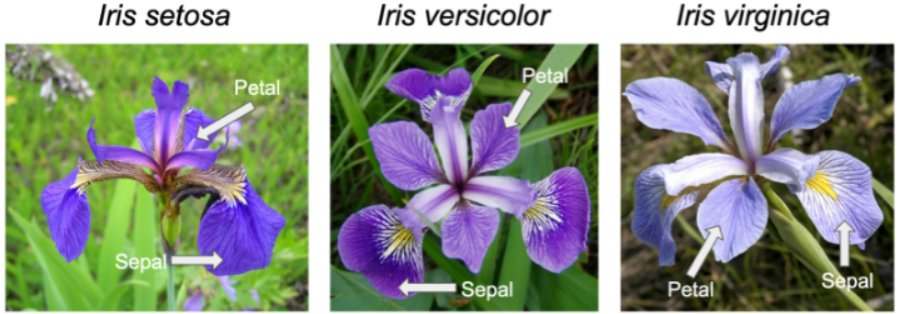

<p align="center">
  <small><b>Figura 6.</b> Especies presentes en el conjunto de datos Iris. <i>Tomado de [Fig. 5].</i></small>
</p>

### Carga y exploración del conjunto de datos:

In [ ]:
# Cargar el conjunto de datos
iris = load_iris()
X, y = iris.data, iris.target

# Construir un DataFrame
iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df["species"] = [iris.target_names[i] for i in y]

# Información general
print(f"Muestras: {X.shape[0]}, Características: {X.shape[1]}, Clases: {', '.join(iris.target_names)}\n")
display(iris_df.head())

Muestras: 150, Características: 4, Clases: setosa, versicolor, virginica



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Distribución de las clases

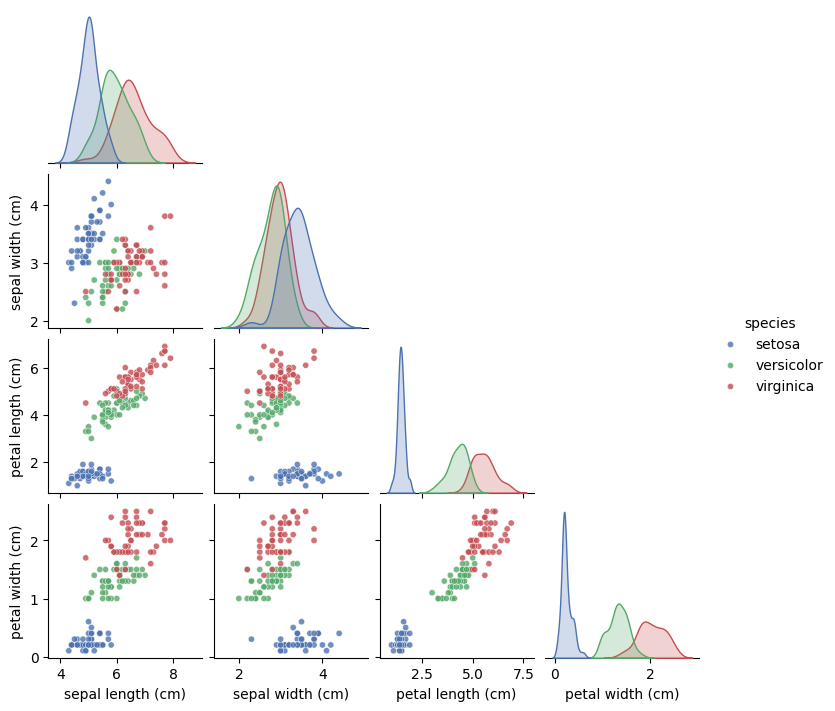

In [ ]:
sns.pairplot(iris_df, vars=iris.feature_names, hue="species", corner=True, diag_kind="kde", palette=["#4C72B0","#55A868","#C44E52"], height=1.8, plot_kws={"s":20,"alpha":0.8})
plt.show()

---

# **1. Repaso de: Variational Quantum Classifier**

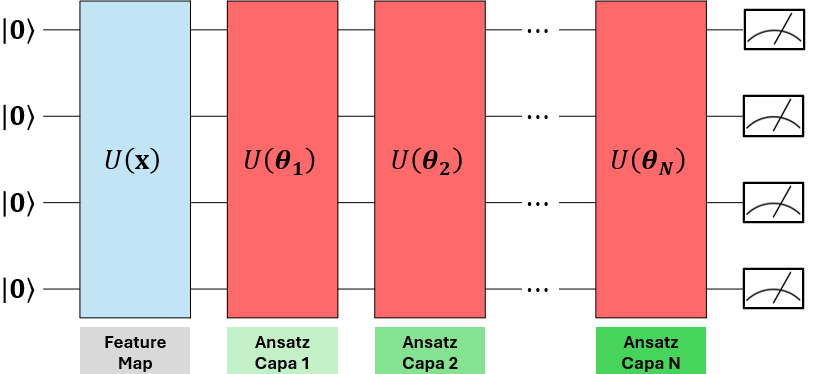

<p align="center">
  <small><b>Figura 3.</b> Variational Quantum Classifier (VQC).</i></small>
</p>

## **1.1 ¿Qué es un VQC?**

<p align="justify" style="text-align: justify; width: 100%;">
Un <b>Variational Quantum Classifier (VQC)</b> es una de las formulaciones más utilizadas para construir una <b>Red Neuronal Cuántica (QNN)</b>. De manera general, un VQC está compuesto por los siguientes elementos:
</p>

<ul>
  <li><b>Feature Map:</b> codifica los datos clásicos dentro del circuito cuántico.</li>
  <li><b>Ansatz:</b> circuito cuántico con parámetros entrenables que procesa la información codificada.</li>
  <li><b>Measurement:</b> realiza la medición del circuito para obtener una salida clásica.</li>
  <li><b>Optimizador clásico:</b> actualiza los parámetros entrenables del circuito durante el proceso de aprendizaje.</li>
</ul>

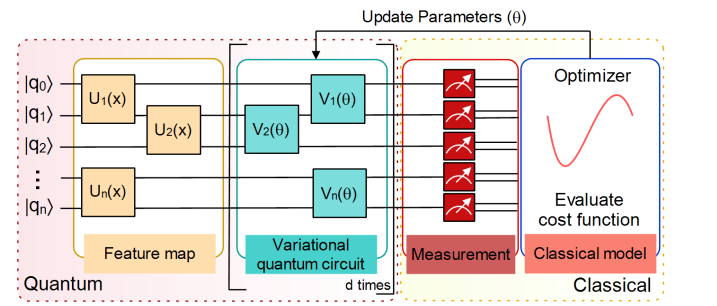

<p align="center">
  <small><b>Figura 7.</b> Estructura general de un Variational Quantum Classifier (VQC). <i>Tomado de [Fig. 6].</i></small>
</p>

Configuración del dispositivo:

In [ ]:
DISPOSITIVO = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo de PyTorch: {DISPOSITIVO}")

Dispositivo de PyTorch: cpu


Parámetros del circuito:

In [ ]:
NUM_QUBITS = 4
NUM_CAPAS = 2

Dispositivo cuántico:

In [ ]:
dispositivo_cuantico = qml.device("default.qubit", wires=NUM_QUBITS)

## **1.2 Codificación de datos**

<p align="justify" style="text-align: justify; width: 100%;">

El <b>Feature Map codifica los datos clásicos</b> dentro del circuito cuántico. Cada una de las <b>cuatro características</b> del conjunto de datos <b>Iris</b> se codifica mediante rotaciones <b>RY</b>, mientras que las compuertas <b>IsingZZ introducen correlaciones entre características vecinas</b>.

</p>

$$
\mathrm{IsingZZ}(\phi)
=
\exp\!\left(
-\frac{i\phi}{2}
\left(
Z\otimes Z
\right)
\right)
=
\begin{bmatrix}
e^{-i\phi/2} & 0 & 0 & 0\\
0 & e^{i\phi/2} & 0 & 0\\
0 & 0 & e^{i\phi/2} & 0\\
0 & 0 & 0 & e^{-i\phi/2}
\end{bmatrix}
$$

In [ ]:
ALPHA = 0.5

def feature_map(x):
    # Codificación local
    for qubit in range(NUM_QUBITS):
        qml.RY(ALPHA * x[qubit], wires=qubit)

    # Interacciones entre características vecinas
    for qubit in range(NUM_QUBITS - 1):
        qml.IsingZZ(
            0.5 * ALPHA * x[qubit] * ALPHA * x[qubit + 1],
            wires=[qubit, qubit + 1]
        )

## **1.3 Ansatz**

<p align="justify" style="text-align: justify; width: 100%;">
El <b>Ansatz</b> es el componente del circuito cuántico que contiene los <b>parámetros entrenables</b>. Su función es transformar el estado preparado por el <b>Feature Map</b> mediante compuertas cuánticas cuyos parámetros serán optimizados durante el entrenamiento.
</p>

<p align="justify" style="text-align: justify; width: 100%;">
En este modelo utilizaremos un ansatz compuesto por:
</p>

<ul>
  <li>Rotaciones <b>RY</b>.</li>
  <li>Rotaciones <b>RZ</b>.</li>
  <li>Una cadena de compuertas <b>CNOT</b> para generar entrelazamiento entre los qubits.</li>
</ul>

<p align="justify" style="text-align: justify; width: 100%;">
Cada capa del ansatz seguirá la siguiente estructura:
</p>

```text
RY → RZ → CNOT

In [ ]:
def ansatz_vqc(pesos):
    for capa in range(NUM_CAPAS):
        for qubit in range(NUM_QUBITS):
            qml.RY(pesos[capa, qubit, 0], wires=qubit)
            qml.RZ(pesos[capa, qubit, 1], wires=qubit)
        for qubit in range(NUM_QUBITS - 1):
            qml.CNOT(wires=[qubit, qubit + 1])
        qml.Barrier()

## **1.4 Medición y salida**

<p align="justify" style="text-align: justify; width: 100%;">

Una vez codificados los datos y procesados por el <b>Ansatz</b>, se calcula el <b>valor esperado</b> de un observable para obtener una salida clásica. En este caso se emplea una <b>medición global</b> mediante el siguiente observable:

</p>

$$
f_{\boldsymbol{\theta}}(\mathbf{x})=
\left\langle
Z_0 \otimes Z_1 \otimes Z_2 \otimes Z_3
\right\rangle
$$

<p align="justify" style="text-align: justify; width: 100%;">

Al actuar sobre los <b>cuatro qubits</b>, este observable produce un <b>único valor esperado</b> comprendido en el intervalo:

</p>

$$
-1 \leq f_{\boldsymbol{\theta}}(\mathbf{x}) \leq 1
$$

<p align="justify" style="text-align: justify; width: 100%;">

Este valor se utiliza posteriormente para calcular la <b>función de pérdida</b> y optimizar los parámetros del circuito durante el entrenamiento.

</p>

Circuito cuántico:

In [ ]:
# QNode convierte la función en un circuito cuántico ejecutable:
@qml.qnode(
    dispositivo_cuantico,     # dispositivo_cuantico : simulador donde se ejecutará el circuito.
    interface="torch",        # interface="torch"    : integra el circuito con PyTorch.
    diff_method="backprop"    # diff_method="backprop": calcula los gradientes mediante backpropagation.
)

def circuito_vqc(x, parametros):
    feature_map(x)        # 1.2
    qml.Barrier()         # Barrera visual
    ansatz_vqc(parametros)    # 1.3

    # Medición global mediante el producto tensorial de los observables Pauli-Z de los cuatro qubits.
    return qml.expval(
      qml.PauliZ(0)
      @ qml.PauliZ(1)
      @ qml.PauliZ(2)
      @ qml.PauliZ(3)
)

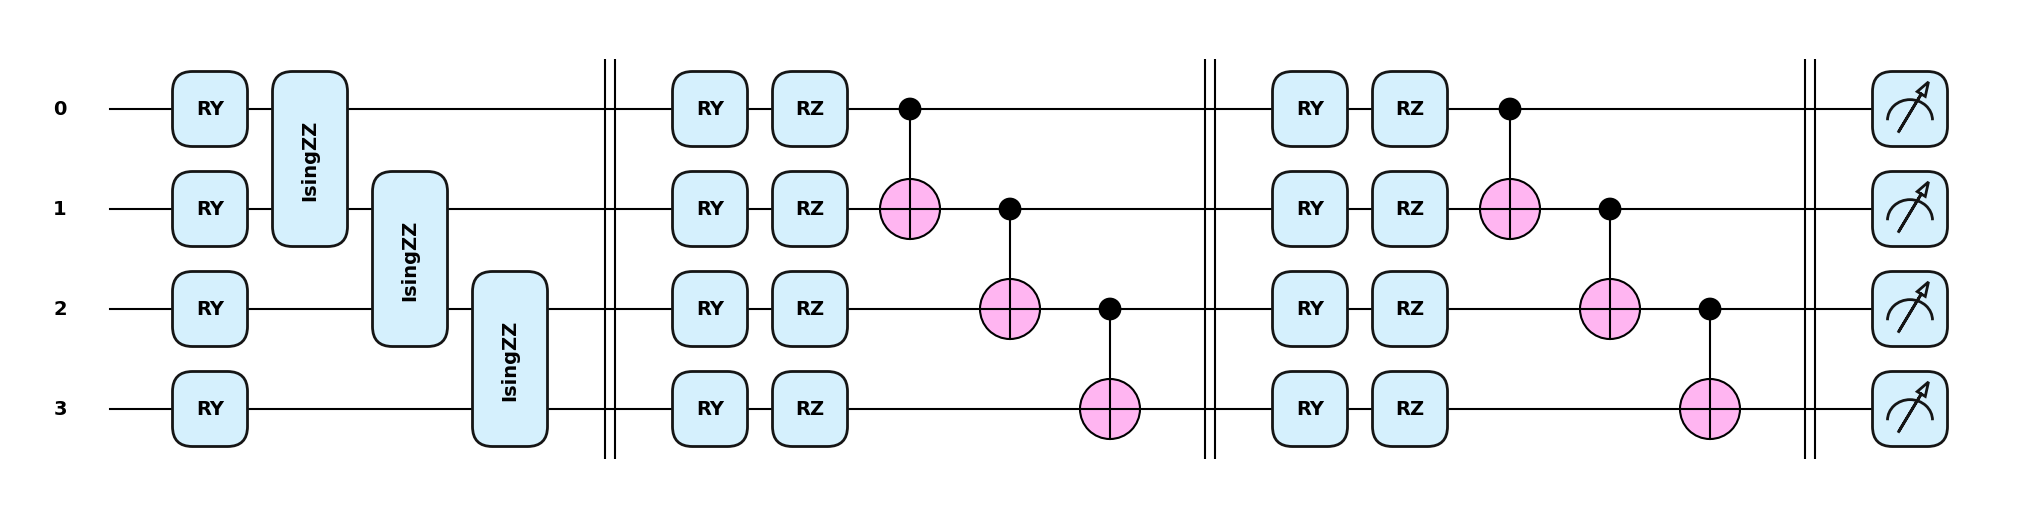

In [ ]:
parametros = torch.zeros((NUM_CAPAS, NUM_QUBITS, 2), dtype=torch.float64)
muestra = torch.tensor(X[0], dtype=torch.float64)
qml.draw_mpl(circuito_vqc, style="pennylane")(muestra, parametros)
plt.show()

## **1.5. Entrenamiento del VQC**

<p align="justify" style="text-align: justify; width: 100%;">
En este ejemplo se utilizarán únicamente <b>dos especies</b> del conjunto de datos <b>Iris</b>: <b>Iris versicolor</b> e <b>Iris virginica</b>, convirtiendo el problema en una tarea de <b>clasificación binaria</b>.
</p>

<p align="justify" style="text-align: justify; width: 100%;">
Posteriormente, las etiquetas se transformarán a los valores <b>-1</b> y <b>+1</b>, los cuales serán utilizados durante el entrenamiento del modelo.
</p>

In [ ]:
clases_seleccionadas = [1, 2] # 1 = versicolor y 2 = virginica

mascara = np.isin(y, clases_seleccionadas)
X_binario, y_binario = X[mascara], y[mascara]
y_binario = np.where(y_binario == 1, -1.0, 1.0)

print("Clases utilizadas:\n- Versicolor: -1\n- Virginica : +1\nNúmero de muestras:", len(X_binario))

Clases utilizadas:
- Versicolor: -1
- Virginica : +1
Número de muestras: 100


<p align="justify" style="text-align: justify; width: 100%;">
El conjunto de datos se dividirá en un <b>75%</b> para <b>entrenamiento</b> y un <b>25%</b> para <b>prueba</b>. Posteriormente, las características se escalarán al intervalo <b>[-π, π]</b> para utilizarlas como ángulos de rotación dentro del <b>Feature Map</b>.
</p>

In [ ]:
# División entrenamiento/prueba
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X_binario, y_binario, test_size=0.25, random_state=SEMILLA, stratify=y_binario
)

# Escalado angular [-π, π]
escalador = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_entrenamiento = escalador.fit_transform(X_entrenamiento)
X_prueba = escalador.transform(X_prueba)

# Conversión a tensores
X_entrenamiento = torch.tensor(X_entrenamiento, dtype=torch.float64)
X_prueba = torch.tensor(X_prueba, dtype=torch.float64)
y_entrenamiento = torch.tensor(y_entrenamiento, dtype=torch.float64)
y_prueba = torch.tensor(y_prueba, dtype=torch.float64)

print(f"Entrenamiento: {len(X_entrenamiento)}, Prueba: {len(X_prueba)}")
print(f"Rango angular: [{X_entrenamiento.min().item():.4f}, {X_entrenamiento.max().item():.4f}]")

Entrenamiento: 75, Prueba: 25
Rango angular: [-3.1416, 3.1416]


### **1.5.1 Modelo, pérdida y optimizador**


<p align="justify" style="text-align: justify; width: 100%;">
A continuación, se define el <b>modelo VQC</b>, la <b>función de pérdida</b> y el <b>optimizador clásico</b> que se utilizarán durante el entrenamiento.

Además, se muestra el número total de <b>parámetros entrenables</b> del modelo.
</p>

In [ ]:
class ClasificadorVQC(nn.Module):
    def __init__(self):
        super().__init__()
        self.parametros = nn.Parameter(0.01 * torch.randn(NUM_CAPAS, NUM_QUBITS, 2, dtype=torch.float64))
    def forward(self, datos):
        return torch.stack([circuito_vqc(muestra, self.parametros) for muestra in datos])

modelo_vqc = ClasificadorVQC()
funcion_perdida_vqc = nn.MSELoss()                                      # Mean Squared Error Loss
optimizador_vqc = torch.optim.Adam(modelo_vqc.parameters(), lr=0.01)    # Optimizador Adam
print("Parámetros entrenables:", modelo_vqc.parametros.numel())

Parámetros entrenables: 16


### **1.5.2 Entrenamiento**

In [ ]:
NUM_EPOCAS = 50
historial_perdida, historial_exactitud = [], []

for epoca in range(1, NUM_EPOCAS + 1):
    modelo_vqc.train()
    optimizador_vqc.zero_grad()
    perdida = funcion_perdida_vqc(modelo_vqc(X_entrenamiento), y_entrenamiento)
    perdida.backward()
    optimizador_vqc.step()

    modelo_vqc.eval()
    with torch.no_grad():
        salidas = modelo_vqc(X_entrenamiento)
        predicciones = torch.where(salidas >= 0, 1.0, -1.0)
        exactitud = (predicciones == y_entrenamiento).double().mean()

    historial_perdida.append(perdida.item())
    historial_exactitud.append(exactitud.item())
    print(f"Época {epoca:02d} | Pérdida: {perdida.item():.4f} | Exactitud: {100 * exactitud.item():.2f}%")

Época 01 | Pérdida: 1.3290 | Exactitud: 57.33%
Época 02 | Pérdida: 1.3067 | Exactitud: 58.67%
Época 03 | Pérdida: 1.2843 | Exactitud: 58.67%
Época 04 | Pérdida: 1.2619 | Exactitud: 58.67%
Época 05 | Pérdida: 1.2395 | Exactitud: 58.67%
Época 06 | Pérdida: 1.2170 | Exactitud: 58.67%
Época 07 | Pérdida: 1.1944 | Exactitud: 58.67%
Época 08 | Pérdida: 1.1718 | Exactitud: 58.67%
Época 09 | Pérdida: 1.1491 | Exactitud: 58.67%
Época 10 | Pérdida: 1.1264 | Exactitud: 58.67%
Época 11 | Pérdida: 1.1037 | Exactitud: 58.67%
Época 12 | Pérdida: 1.0811 | Exactitud: 58.67%
Época 13 | Pérdida: 1.0585 | Exactitud: 61.33%
Época 14 | Pérdida: 1.0361 | Exactitud: 61.33%
Época 15 | Pérdida: 1.0138 | Exactitud: 61.33%
Época 16 | Pérdida: 0.9917 | Exactitud: 61.33%
Época 17 | Pérdida: 0.9699 | Exactitud: 61.33%
Época 18 | Pérdida: 0.9482 | Exactitud: 61.33%
Época 19 | Pérdida: 0.9268 | Exactitud: 61.33%
Época 20 | Pérdida: 0.9057 | Exactitud: 62.67%
Época 21 | Pérdida: 0.8849 | Exactitud: 62.67%
Época 22 | Pé

## **1.6 Resultados del VQC**

<p align="justify" style="text-align: justify; width: 100%;">
La <b>exactitud</b> (<i>Accuracy</i>) mide la proporción de muestras clasificadas correctamente respecto al número total de muestras evaluadas.
</p>

$$
\mathrm{Exactitud}
=
\frac{\text{Predicciones correctas}}
{\text{Número total de muestras}}
$$

In [ ]:
with torch.no_grad():
    pred_ent = torch.where(modelo_vqc(X_entrenamiento) >= 0, 1.0, -1.0)
    pred_prue = torch.where(modelo_vqc(X_prueba) >= 0, 1.0, -1.0)
    exact_ent = (pred_ent == y_entrenamiento).double().mean()
    exact_prue = (pred_prue == y_prueba).double().mean()

print(f"Exactitud entrenamiento: {100 * exact_ent.item():.2f}%")
print(f"Exactitud prueba: {100 * exact_prue.item():.2f}%")

Exactitud entrenamiento: 86.67%
Exactitud prueba: 84.00%


Curvas de pérdida y exactitud:

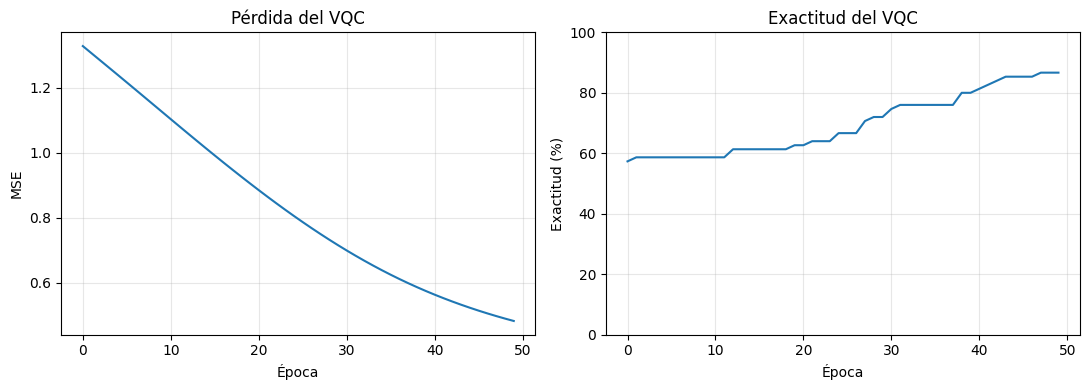

In [ ]:
historial_exactitud_porcentaje = [100 * v for v in historial_exactitud]

fig, ejes = plt.subplots(1, 2, figsize=(11, 4))

ejes[0].plot(historial_perdida)
ejes[0].set_xlabel("Época"); ejes[0].set_ylabel("MSE"); ejes[0].set_title("Pérdida del VQC"); ejes[0].grid(alpha=0.3)

ejes[1].plot(historial_exactitud_porcentaje)
ejes[1].set_xlabel("Época"); ejes[1].set_ylabel("Exactitud (%)"); ejes[1].set_title("Exactitud del VQC"); ejes[1].set_ylim(0, 100); ejes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

---

# **2. Data Re-uploading Quantum Neural Network**

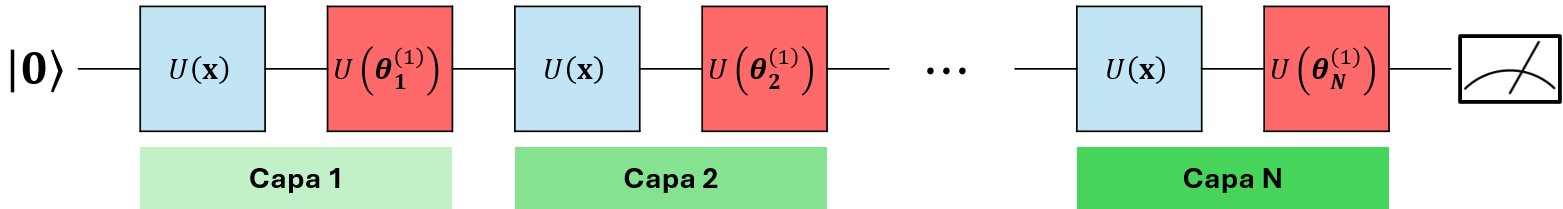

<p align="center">
  <small><b>Figura 4.</b> Data Re-uploading Quantum Neural Network (DRQNN).</i></small>
</p>

## **2.1 ¿Qué es Data Re-uploading?**

<p align="justify" style="text-align: justify; width: 100%;">
Una <b>Data Re-uploading Quantum Neural Network (DRQNN)</b> es una Red Neuronal Cuántica en la que los datos de entrada se codifican repetidamente a lo largo del circuito. Cada capa alterna la <b>misma unidad de codificación de datos</b> \(U(\mathbf{x})\) y una <b>unidad variacional entrenable</b> \(U(\boldsymbol{\theta}_{\ell})\).
</p>

<p align="justify" style="text-align: justify; width: 100%;">
Para una DRQNN de <b>N capas</b>, esta estructura puede representarse como:
</p>

$$
U(\mathbf{x})
\rightarrow
U(\boldsymbol{\theta}_{1})
\rightarrow
U(\mathbf{x})
\rightarrow
U(\boldsymbol{\theta}_{2})
\rightarrow
\cdots
\rightarrow
U(\mathbf{x})
\rightarrow
U(\boldsymbol{\theta}_{N})
$$

<p align="justify" style="text-align: justify; width: 100%;">
En este ejemplo se utilizará <b>un qubit</b>, <b>tres características</b> del conjunto de datos <b>Iris</b> y <b>seis capas de Data Re-uploading</b>. Al finalizar el circuito, se realizará una medición para obtener la salida del clasificador.
</p>

En este ejemplo utilizaremos **un único qubit**, **tres características** y **seis capas de Data Re-uploading**, construyendo explícitamente cada bloque mediante rotaciones elementales.

Parámetros del circuito:

In [ ]:
NUM_QUBITS_DR = 1
NUM_CAPAS_DR = 6

Dispositivo cuántico:

In [ ]:
dispositivo_dr = qml.device("default.qubit", wires=NUM_QUBITS_DR)

## **2.2 Codificación de datos**

<p align="justify" style="text-align: justify; width: 100%;">
A diferencia del <b>VQC</b> desarrollado anteriormente, donde cada característica se codifica en un qubit diferente, en una <b>DRQNN</b> la misma información se introduce repetidamente sobre <b>un único qubit</b>. En este ejemplo se utilizarán <b>tres características</b> del conjunto de datos <b>Iris</b>, las cuales se codificarán mediante una secuencia de rotaciones elementales.
</p>

<p align="justify" style="text-align: justify; width: 100%;">
La unidad de codificación de datos utilizada en cada capa estará dada por:
</p>

$$
U(\mathbf{x})
=
R_Z(x_1)\,
R_Y(x_2)\,
R_Z(x_3)
$$

In [ ]:
def codificacion_datos(x, qubit=0):
    qml.RZ(x[0], wires=qubit)
    qml.RY(x[1], wires=qubit)
    qml.RZ(x[2], wires=qubit)

## **2.3 Ansatz parametrizado**

In [ ]:
def ansatz_dr(parametros, qubit=0):
    qml.RZ(parametros[0], wires=qubit)
    qml.RY(parametros[1], wires=qubit)
    qml.RZ(parametros[2], wires=qubit)

<p align="justify" style="text-align: justify; width: 100%;">
Después de cada unidad de codificación de datos <b>U(<b>x</b>)</b>, se aplica una <b>unidad entrenable</b> <b>U(<b>θ</b><sub>ℓ</sub>)</b>, cuyos parámetros serán optimizados durante el entrenamiento. En este ejemplo, dicha unidad estará formada por tres compuertas de rotación.
</p>

<p align="justify" style="text-align: justify; width: 100%;">
La unidad entrenable utilizada en cada capa estará dada por:
</p>

$$
U(\boldsymbol{\theta}_{\ell})
=
R_Z(\theta_{\ell,1})\,
R_Y(\theta_{\ell,2})\,
R_Z(\theta_{\ell,3})
$$

## **2.4 Medición y salida**

<p align="justify" style="text-align: justify; width: 100%;">
El circuito se construye alternando la unidad de codificación de datos <b>U(<b>x</b>)</b> y la <b>unidad entrenable </b> <b>U(<b>θ</b><sub>ℓ</sub>)</b> durante seis capas de <b>Data Re-uploading</b> en este caso. Finalmente, se mide el valor esperado del observable <b>Pauli-Z</b> sobre el único qubit.
</p>

<p align="justify" style="text-align: justify; width: 100%;">
La salida del clasificador está dada por:
</p>

$$
f_{\boldsymbol{\theta}}(\mathbf{x})
=
\langle Z_0 \rangle
$$

Circuito cuántico:

In [ ]:
# QNode convierte la función en un circuito cuántico ejecutable:
@qml.qnode(
    dispositivo_dr,           # dispositivo_cuantico : simulador donde se ejecutará el circuito.
    interface="torch",        # interface="torch"    : integra el circuito con PyTorch.
    diff_method="backprop"    # diff_method="backprop": calcula los gradientes mediante backpropagation.
)

def circuito_dr(x, parametros):
    for capa in range(NUM_CAPAS_DR):
        codificacion_datos(x)
        qml.Barrier()         # Barrera visual
        ansatz_dr(parametros[capa])
        qml.Barrier()         # Barrera visual
    return qml.expval(qml.PauliZ(0))

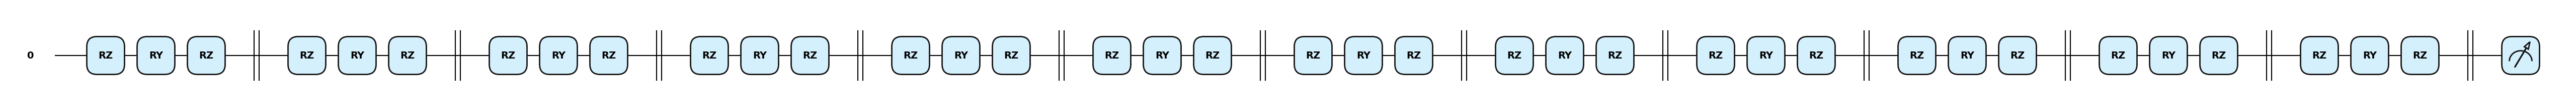

In [ ]:
parametros_ejemplo_dr = torch.zeros((NUM_CAPAS_DR, 3), dtype=torch.float64)
muestra_dr = torch.tensor(X_binario[0, [0, 2, 3]], dtype=torch.float64)
fig, ax = qml.draw_mpl(circuito_dr, style="pennylane")(muestra_dr, parametros_ejemplo_dr)
plt.show()

## **2.5 Entrenamiento de la DRQNN**

Preparación de los datos:

In [ ]:
# Selección de características [0, 2, 3]
X_binario_dr = X_binario[:, [0, 2, 3]]

# División entrenamiento/prueba
X_entrenamiento_dr, X_prueba_dr, y_entrenamiento_dr, y_prueba_dr = train_test_split(
    X_binario_dr, y_binario, test_size=0.25, random_state=SEMILLA, stratify=y_binario
)

# Escalado angular [-π, π]
escalador_dr = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_entrenamiento_dr = torch.tensor(escalador_dr.fit_transform(X_entrenamiento_dr), dtype=torch.float64)
X_prueba_dr = torch.tensor(escalador_dr.transform(X_prueba_dr), dtype=torch.float64)
y_entrenamiento_dr = torch.tensor(y_entrenamiento_dr, dtype=torch.float64)
y_prueba_dr = torch.tensor(y_prueba_dr, dtype=torch.float64)

print("Características: Longitud sépalo, Longitud pétalo, Ancho pétalo")
print(f"Entrenamiento: {len(X_entrenamiento_dr)}, Prueba: {len(X_prueba_dr)}")
print(f"Rango angular: [{X_entrenamiento_dr.min().item():.4f}, {X_entrenamiento_dr.max().item():.4f}]")

Características: Longitud sépalo, Longitud pétalo, Ancho pétalo
Entrenamiento: 75, Prueba: 25
Rango angular: [-3.1416, 3.1416]


### **2.5.1 Modelo, pérdida y optimizador**


In [ ]:
class ClasificadorDRQNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.parametros = nn.Parameter(0.01 * torch.randn(NUM_CAPAS_DR, 3, dtype=torch.float64))

    def forward(self, datos):
        return torch.stack([circuito_dr(muestra, self.parametros) for muestra in datos])

modelo_dr = ClasificadorDRQNN()
funcion_perdida_dr = nn.MSELoss()                                   # Mean Squared Error Loss
optimizador_dr = torch.optim.Adam(modelo_dr.parameters(), lr=0.01)  # Optimizador Adam
print("Parámetros entrenables:", modelo_dr.parametros.numel())

Parámetros entrenables: 18


### **2.5.2 Entrenamiento**

In [ ]:
NUM_EPOCAS_DR = 80
historial_perdida_dr, historial_exactitud_dr = [], []

for epoca in range(1, NUM_EPOCAS_DR + 1):
    modelo_dr.train()
    optimizador_dr.zero_grad()
    perdida = funcion_perdida_dr(modelo_dr(X_entrenamiento_dr), y_entrenamiento_dr)
    perdida.backward()
    optimizador_dr.step()

    modelo_dr.eval()
    with torch.no_grad():
        exactitud = (torch.where(modelo_dr(X_entrenamiento_dr) >= 0, 1.0, -1.0) == y_entrenamiento_dr).double().mean()

    historial_perdida_dr.append(perdida.item())
    historial_exactitud_dr.append(exactitud.item())
    print(f"Época {epoca:02d} | Pérdida: {perdida.item():.4f} | Exactitud: {100 * exactitud.item():.2f}%")

Época 01 | Pérdida: 1.4400 | Exactitud: 53.33%
Época 02 | Pérdida: 1.4229 | Exactitud: 53.33%
Época 03 | Pérdida: 1.4060 | Exactitud: 56.00%
Época 04 | Pérdida: 1.3893 | Exactitud: 56.00%
Época 05 | Pérdida: 1.3729 | Exactitud: 56.00%
Época 06 | Pérdida: 1.3568 | Exactitud: 56.00%
Época 07 | Pérdida: 1.3410 | Exactitud: 57.33%
Época 08 | Pérdida: 1.3255 | Exactitud: 57.33%
Época 09 | Pérdida: 1.3103 | Exactitud: 57.33%
Época 10 | Pérdida: 1.2954 | Exactitud: 57.33%
Época 11 | Pérdida: 1.2807 | Exactitud: 58.67%
Época 12 | Pérdida: 1.2661 | Exactitud: 58.67%
Época 13 | Pérdida: 1.2517 | Exactitud: 58.67%
Época 14 | Pérdida: 1.2373 | Exactitud: 58.67%
Época 15 | Pérdida: 1.2230 | Exactitud: 60.00%
Época 16 | Pérdida: 1.2087 | Exactitud: 60.00%
Época 17 | Pérdida: 1.1944 | Exactitud: 60.00%
Época 18 | Pérdida: 1.1801 | Exactitud: 60.00%
Época 19 | Pérdida: 1.1659 | Exactitud: 58.67%
Época 20 | Pérdida: 1.1517 | Exactitud: 57.33%
Época 21 | Pérdida: 1.1376 | Exactitud: 57.33%
Época 22 | Pé

## **2.6 Resultados del DR QNN**

La exactitud:

In [ ]:
with torch.no_grad():
    pred_ent = torch.where(modelo_dr(X_entrenamiento_dr) >= 0, 1.0, -1.0)
    pred_prue = torch.where(modelo_dr(X_prueba_dr) >= 0, 1.0, -1.0)
    exact_ent = (pred_ent == y_entrenamiento_dr).double().mean()
    exact_prue = (pred_prue == y_prueba_dr).double().mean()

print(f"Exactitud entrenamiento: {100 * exact_ent.item():.2f}%")
print(f"Exactitud prueba: {100 * exact_prue.item():.2f}%")

Exactitud entrenamiento: 74.67%
Exactitud prueba: 72.00%


Curvas de pérdida y exactitud:

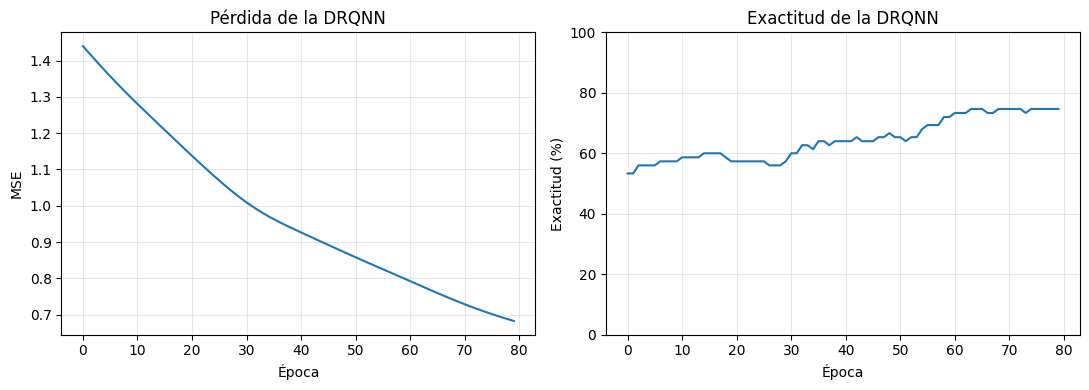

In [ ]:
historial_exactitud_porcentaje_dr = [100 * v for v in historial_exactitud_dr]

fig, ejes = plt.subplots(1, 2, figsize=(11, 4))

ejes[0].plot(historial_perdida_dr)
ejes[0].set_xlabel("Época"); ejes[0].set_ylabel("MSE"); ejes[0].set_title("Pérdida de la DRQNN"); ejes[0].grid(alpha=0.3)

ejes[1].plot(historial_exactitud_porcentaje_dr)
ejes[1].set_xlabel("Época"); ejes[1].set_ylabel("Exactitud (%)"); ejes[1].set_title("Exactitud de la DRQNN"); ejes[1].set_ylim(0, 100); ejes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

---

# **3. Data Re-uploading Quantum Neural Network Escalable**


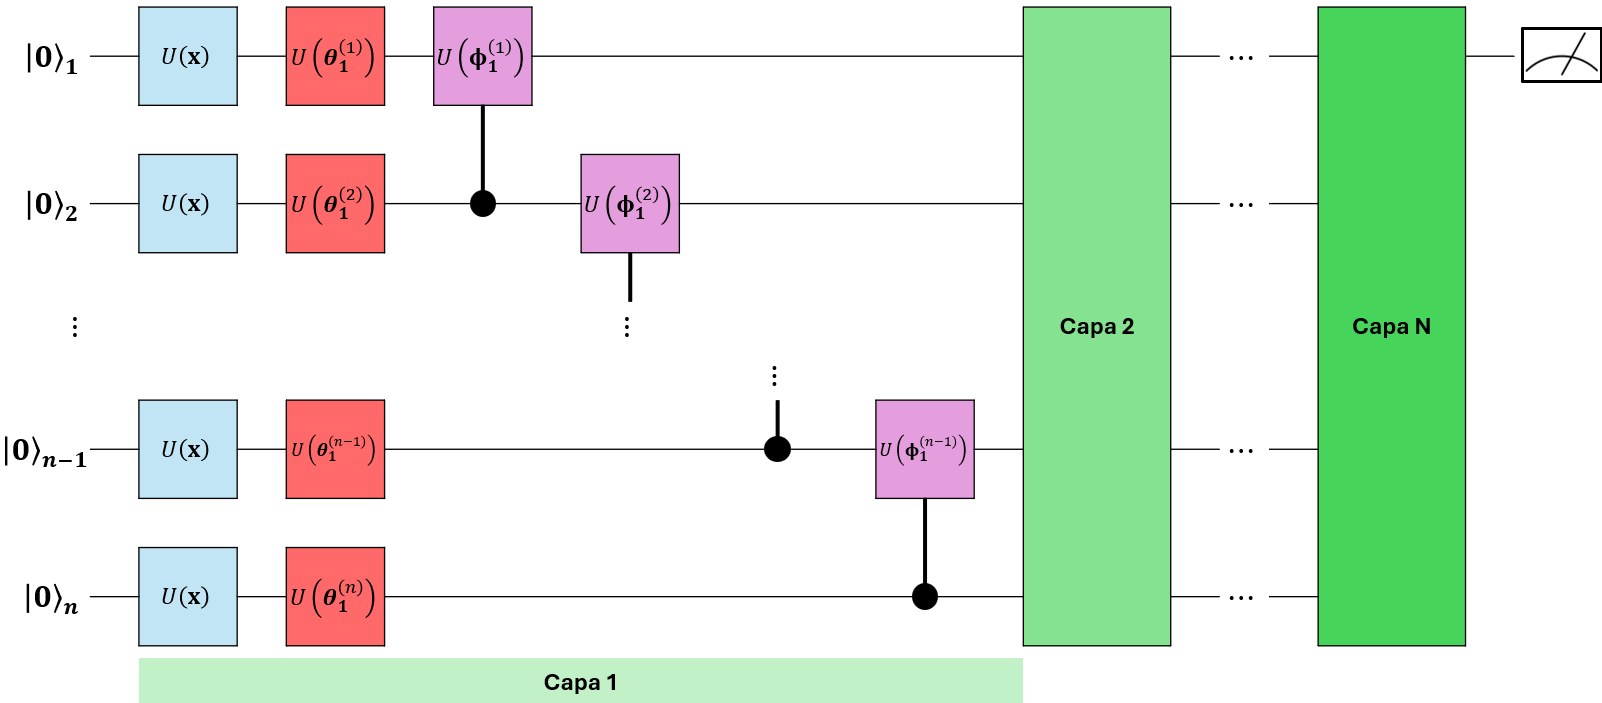

<p align="center">
  <small><b>Figura 5.</b> Extensión escalable de una DRQNN.</i></small>
</p>

## **3.1 ¿Qué es una DR-QNN escalable?**

<p align="justify" style="text-align: justify; width: 100%;">
En la sección anterior se presentó una <b>Data Re-uploading Quantum Neural Network (DRQNN)</b> formada por un único qubit. En esta sección se introduce una extensión escalable de dicha arquitectura, en la cual el circuito crece progresivamente mediante la incorporación de nuevos <b>bloques cuánticos</b>.
</p>

<p align="justify" style="text-align: justify; width: 100%;">

A diferencia de entrenar cada modelo desde cero, los <b>parámetros aprendidos en una etapa se reutilizan para inicializar la siguiente</b>. De esta forma, se entrenan <b>tanto los parámetros de bloques anteriores como los asociados al nuevo bloque y a sus compuertas de acoplamiento</b>, <b>conservando el conocimiento adquirido previamente</b>.

</p>

$$
\boxed{\text{DR-QNN (1 bloque)}}
\;
\xrightarrow{\substack{\text{Guardar y reutilizar}\\ \text{parámetros}}}
\;
\boxed{\text{DR-QNN (2 bloques)}}
\;
\xrightarrow{\substack{\text{Guardar y reutilizar}\\ \text{parámetros}}}
\;
\boxed{\text{DR-QNN (3 bloques)}}
$$

Configuración del entrenamiento progresivo:

In [ ]:
NUM_BLOQUES_LISTA = [1, 2, 3]
resultados_escalables = []
parametros_previos = None

Selección de número de bloques cuánticos:

In [ ]:
NUM_BLOQUES = 3

<p align="justify" style="text-align: justify; width: 100%;">

El <b>acoplamiento entre los bloques de Data Re-uploading</b> se realiza mediante una <b>compuerta Rot controlada</b>. La compuerta <b>Rot</b> implementa una rotación arbitraria de un qubit mediante <b>tres parámetros entrenables</b>.

</p>

$$
\mathrm{Rot}(\phi,\theta,\omega)
=
R_Z(\omega)\,
R_Y(\theta)\,
R_Z(\phi)
=
\begin{bmatrix}
e^{-i(\phi+\omega)/2}\cos\!\left(\frac{\theta}{2}\right)
&
-\,e^{-i(\phi-\omega)/2}\sin\!\left(\frac{\theta}{2}\right)
\\[1.2em]
e^{\,i(\phi-\omega)/2}\sin\!\left(\frac{\theta}{2}\right)
&
e^{\,i(\phi+\omega)/2}\cos\!\left(\frac{\theta}{2}\right)
\end{bmatrix}
$$

## **3.2 Circuito escalable**

La DR-QNN de un bloque presentada en la sección anterior se extiende reutilizando las funciones `codificacion_datos()` y `ansatz_dr()`. Cada bloque representa un qubit que procesa la misma información de entrada y posteriormente se conecta con el bloque anterior mediante una operación controlada. De esta forma, el circuito puede crecer progresivamente sin modificar su estructura base.

Rotación entre bloques cuánticos:

In [ ]:
def acoplamiento_bloques(parametros, control, objetivo):
    qml.ctrl(qml.Rot, control=control)(
        parametros[0],
        parametros[1],
        parametros[2],
        wires=objetivo
    )

Circuito cuántico:

In [ ]:
# QNode convierte la función en un circuito cuántico ejecutable:
def crear_circuito_escalable(num_bloques):

    dispositivo_escalable = qml.device("default.qubit", wires=num_bloques)

    @qml.qnode(
        dispositivo_escalable,     # dispositivo_escalable : simulador donde se ejecutará el circuito.
        interface="torch",         # interface="torch"    : integra el circuito con PyTorch.
        diff_method="backprop"     # diff_method="backprop": calcula los gradientes mediante backpropagation.
    )

    def circuito_escalable(x, parametros_locales, parametros_controlados):

        for capa in range(NUM_CAPAS_DR):

            # Codificación de datos en cada bloque cuántico.
            for bloque in range(num_bloques):
                codificacion_datos(x, bloque)

            qml.Barrier()          # Barrera visual

            # Ansatz parametrizado en cada bloque cuántico.
            for bloque in range(num_bloques):
                ansatz_dr(parametros_locales[capa, bloque], bloque)

            qml.Barrier()          # Barrera visual

            # Acoplamiento progresivo entre bloques cuánticos.
            for bloque in range(1, num_bloques):
                acoplamiento_bloques(parametros_controlados[capa, bloque - 1], control=bloque, objetivo=bloque - 1)

            qml.Barrier()          # Barrera visual

        return qml.expval(qml.PauliZ(0))

    return circuito_escalable

Clase para los modelos escalables:

In [ ]:
class ClasificadorDRQNNEscalable(nn.Module):
    def __init__(self, num_bloques, params_loc_prev=None, params_ctrl_prev=None):
        super().__init__()
        self.num_bloques = num_bloques
        self.circuito = crear_circuito_escalable(num_bloques)
        params_loc = 0.01 * torch.randn(NUM_CAPAS_DR, num_bloques, 3, dtype=torch.float64)
        params_ctrl = torch.zeros(NUM_CAPAS_DR, max(0, num_bloques - 1), 3, dtype=torch.float64)
        if params_loc_prev is not None:
            params_loc[:, :params_loc_prev.shape[1], :] = params_loc_prev
        if params_ctrl_prev is not None and params_ctrl_prev.numel() > 0:
            params_ctrl[:, :params_ctrl_prev.shape[1], :] = params_ctrl_prev
        self.parametros_locales = nn.Parameter(params_loc)
        self.parametros_controlados = nn.Parameter(params_ctrl)

    def forward(self, datos):
        return torch.stack([self.circuito(m, self.parametros_locales, self.parametros_controlados) for m in datos])

Entrenamiento del modelo:

In [ ]:
def entrenar_modelo_escalable(modelo, num_epocas):
    optimizador = torch.optim.Adam(modelo.parameters(), lr=0.01)
    perdida_fn = nn.MSELoss()
    historia_perdida, historia_exactitud = [], []
    mejor_perdida = float("inf")
    mejores_locales = mejores_controlados = None

    for epoca in range(1, num_epocas + 1):
        modelo.train()
        optimizador.zero_grad()
        perdida = perdida_fn(modelo(X_entrenamiento_dr), y_entrenamiento_dr)
        perdida.backward()
        optimizador.step()

        modelo.eval()
        with torch.no_grad():
            salidas = modelo(X_entrenamiento_dr)
            exactitud = (torch.where(salidas >= 0, 1.0, -1.0) == y_entrenamiento_dr).double().mean()
            perdida_actual = perdida_fn(salidas, y_entrenamiento_dr)

        historia_perdida.append(perdida_actual.item())
        historia_exactitud.append(exactitud.item())

        if perdida_actual.item() < mejor_perdida:
            mejor_perdida = perdida_actual.item()
            mejores_locales = modelo.parametros_locales.detach().clone()
            mejores_controlados = modelo.parametros_controlados.detach().clone()

        print(f"Época {epoca:02d} | Pérdida: {perdida_actual.item():.4f} | Exactitud: {100 * exactitud.item():.2f}%")

    with torch.no_grad():
        modelo.parametros_locales.copy_(mejores_locales)
        modelo.parametros_controlados.copy_(mejores_controlados)

    return modelo, historia_perdida, historia_exactitud

In [ ]:
modelos, historiales, resultados = [], [], []

def evaluar_y_guardar_modelo(modelo, num_bloques, historial_perdida, historial_exactitud):
    modelo.eval()
    with torch.no_grad():
        acc_train = (torch.where(modelo(X_entrenamiento_dr) >= 0, 1.0, -1.0) == y_entrenamiento_dr).double().mean()
        acc_test = (torch.where(modelo(X_prueba_dr) >= 0, 1.0, -1.0) == y_prueba_dr).double().mean()

    modelos.append(modelo)
    historiales.append({"bloques": num_bloques, "perdida": historial_perdida.copy(), "exactitud": historial_exactitud.copy()})
    resultados.append({"bloques": num_bloques, "train_acc": acc_train.item(), "test_acc": acc_test.item(),
                       "parametros_locales": modelo.parametros_locales.detach().clone(),
                       "parametros_controlados": modelo.parametros_controlados.detach().clone()})
    print(f"Train: {100*acc_train.item():.2f}% | Test: {100*acc_test.item():.2f}%")

In [ ]:
def dibujar_circuito_escalable(num_bloques):
    fig, ax = qml.draw_mpl(crear_circuito_escalable(num_bloques), style="pennylane")(
        X_entrenamiento_dr[0],
        torch.zeros((NUM_CAPAS_DR, num_bloques, 3), dtype=torch.float64),
        torch.zeros((NUM_CAPAS_DR, num_bloques - 1, 3), dtype=torch.float64)
    )
    plt.show()

## **3.3 Modelo de 1 bloque**

El modelo de un bloque corresponde a la DR-QNN entrenada en la sección anterior. Sus parámetros, historial y resultados se conservan como punto de partida para construir los modelos siguientes.

Dibujar el circuito:

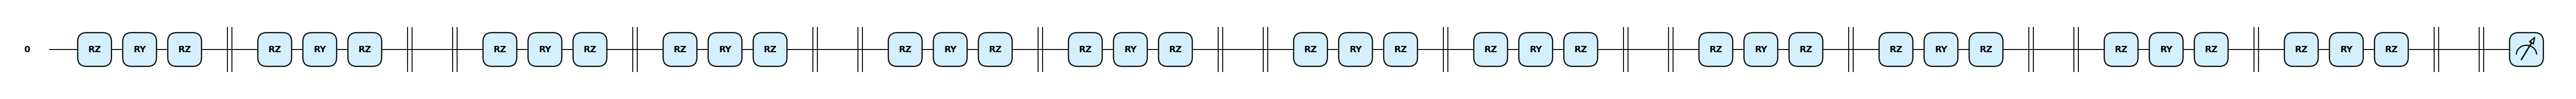

In [ ]:
NUM_BLOQUES_ACTUAL = 1
dibujar_circuito_escalable(NUM_BLOQUES_ACTUAL)

Construir modelo:

In [ ]:
params_loc_prev = modelo_dr.parametros.detach().clone().unsqueeze(1)
params_ctrl_prev = None
modelo_1_bloque = ClasificadorDRQNNEscalable(NUM_BLOQUES_ACTUAL, params_loc_prev, params_ctrl_prev)
hist_perdida_1 = historial_perdida_dr.copy()
hist_exactitud_1 = historial_exactitud_dr.copy()
print("Params entrenables:", sum(p.numel() for p in modelo_1_bloque.parameters()))

Params entrenables: 18


Evaluar y guardar:

In [ ]:
evaluar_y_guardar_modelo(modelo_1_bloque, NUM_BLOQUES_ACTUAL, hist_perdida_1, hist_exactitud_1)
params_loc_1 = modelo_1_bloque.parametros_locales.detach().clone()
params_ctrl_1 = modelo_1_bloque.parametros_controlados.detach().clone()

Train: 74.67% | Test: 72.00%


## **3.4 Modelo de 2 bloques**

El primer bloque conserva los parámetros aprendidos anteriormente. El segundo bloque se inicializa con parámetros nuevos y el acoplamiento comienza como la identidad.

Dibujar el circuito:

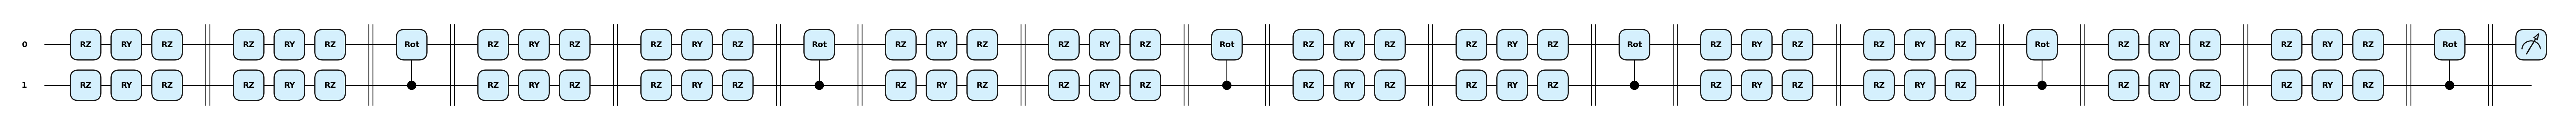

In [ ]:
NUM_BLOQUES_ACTUAL = 2
dibujar_circuito_escalable(NUM_BLOQUES_ACTUAL)

Construir modelo:

In [ ]:
modelo_2_bloques = ClasificadorDRQNNEscalable(NUM_BLOQUES_ACTUAL, params_loc_1, params_ctrl_1)
print("Params entrenables:", sum(p.numel() for p in modelo_2_bloques.parameters()))

Params entrenables: 54


Entrenar:

In [ ]:
modelo_2_bloques, hist_perdida_2, hist_exactitud_2 = entrenar_modelo_escalable(modelo_2_bloques, 40)

Época 01 | Pérdida: 0.6686 | Exactitud: 72.00%
Época 02 | Pérdida: 0.6591 | Exactitud: 73.33%
Época 03 | Pérdida: 0.6498 | Exactitud: 76.00%
Época 04 | Pérdida: 0.6408 | Exactitud: 74.67%
Época 05 | Pérdida: 0.6320 | Exactitud: 76.00%
Época 06 | Pérdida: 0.6234 | Exactitud: 76.00%
Época 07 | Pérdida: 0.6151 | Exactitud: 76.00%
Época 08 | Pérdida: 0.6071 | Exactitud: 76.00%
Época 09 | Pérdida: 0.5994 | Exactitud: 78.67%
Época 10 | Pérdida: 0.5919 | Exactitud: 80.00%
Época 11 | Pérdida: 0.5848 | Exactitud: 81.33%
Época 12 | Pérdida: 0.5779 | Exactitud: 81.33%
Época 13 | Pérdida: 0.5712 | Exactitud: 81.33%
Época 14 | Pérdida: 0.5648 | Exactitud: 84.00%
Época 15 | Pérdida: 0.5585 | Exactitud: 84.00%
Época 16 | Pérdida: 0.5523 | Exactitud: 85.33%
Época 17 | Pérdida: 0.5464 | Exactitud: 85.33%
Época 18 | Pérdida: 0.5406 | Exactitud: 86.67%
Época 19 | Pérdida: 0.5349 | Exactitud: 86.67%
Época 20 | Pérdida: 0.5294 | Exactitud: 88.00%
Época 21 | Pérdida: 0.5240 | Exactitud: 89.33%
Época 22 | Pé

Evaluar y guardar:

In [ ]:
evaluar_y_guardar_modelo(modelo_2_bloques, NUM_BLOQUES_ACTUAL, hist_perdida_2, hist_exactitud_2)
params_loc_2, params_ctrl_2 = modelo_2_bloques.parametros_locales.detach().clone(), modelo_2_bloques.parametros_controlados.detach().clone()

Train: 88.00% | Test: 84.00%


## **3.5 Modelo de 3 bloques**

Los dos primeros bloques conservan los parámetros aprendidos anteriormente. El tercer bloque se inicializa con parámetros nuevos y el nuevo acoplamiento comienza como la identidad.

Dibujar circuito:

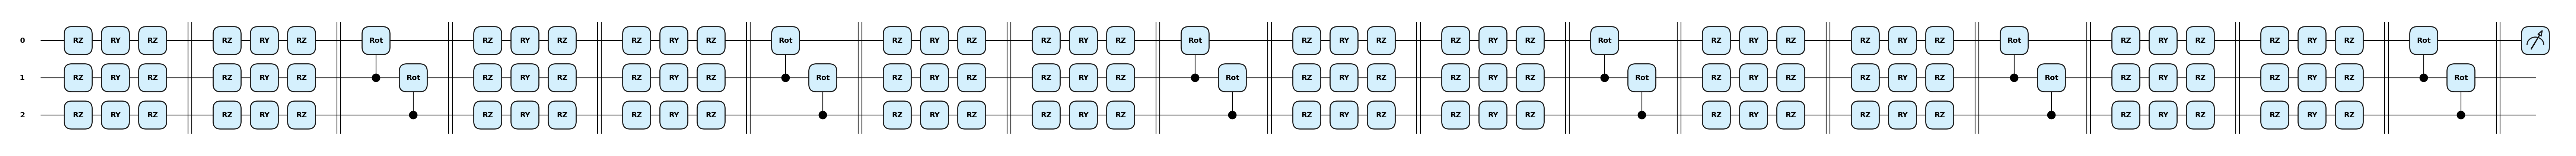

In [ ]:
NUM_BLOQUES_ACTUAL = 3
dibujar_circuito_escalable(NUM_BLOQUES_ACTUAL)

Construir modelo:

In [ ]:
modelo_3_bloques = ClasificadorDRQNNEscalable(NUM_BLOQUES_ACTUAL, params_loc_2, params_ctrl_2)
print("Params entrenables:", sum(p.numel() for p in modelo_3_bloques.parameters()))

Params entrenables: 90


Entrenar:

In [ ]:
modelo_3_bloques, hist_perdida_3, hist_exactitud_3 = entrenar_modelo_escalable(modelo_3_bloques, 20)

Época 01 | Pérdida: 0.4338 | Exactitud: 89.33%
Época 02 | Pérdida: 0.4295 | Exactitud: 89.33%
Época 03 | Pérdida: 0.4254 | Exactitud: 89.33%
Época 04 | Pérdida: 0.4214 | Exactitud: 89.33%
Época 05 | Pérdida: 0.4174 | Exactitud: 89.33%
Época 06 | Pérdida: 0.4136 | Exactitud: 89.33%
Época 07 | Pérdida: 0.4098 | Exactitud: 89.33%
Época 08 | Pérdida: 0.4061 | Exactitud: 89.33%
Época 09 | Pérdida: 0.4025 | Exactitud: 90.67%
Época 10 | Pérdida: 0.3989 | Exactitud: 90.67%
Época 11 | Pérdida: 0.3954 | Exactitud: 89.33%
Época 12 | Pérdida: 0.3919 | Exactitud: 89.33%
Época 13 | Pérdida: 0.3885 | Exactitud: 89.33%
Época 14 | Pérdida: 0.3851 | Exactitud: 89.33%
Época 15 | Pérdida: 0.3817 | Exactitud: 89.33%
Época 16 | Pérdida: 0.3784 | Exactitud: 89.33%
Época 17 | Pérdida: 0.3752 | Exactitud: 89.33%
Época 18 | Pérdida: 0.3720 | Exactitud: 89.33%
Época 19 | Pérdida: 0.3688 | Exactitud: 89.33%
Época 20 | Pérdida: 0.3658 | Exactitud: 89.33%


Evaluar y guardar:

In [ ]:
evaluar_y_guardar_modelo(modelo_3_bloques, NUM_BLOQUES_ACTUAL, hist_perdida_3, hist_exactitud_3)
params_loc_3, params_ctrl_3 = modelo_3_bloques.parametros_locales.detach().clone(), modelo_3_bloques.parametros_controlados.detach().clone()

Train: 89.33% | Test: 88.00%


## **3.6 Resultados**

In [ ]:
for resultado in resultados:
    print(f"\n{resultado['bloques']} bloque(s)")
    print(f"Train: {100*resultado['train_acc']:.2f}%")
    print(f"Test : {100*resultado['test_acc']:.2f}%")


1 bloque(s)
Train: 74.67%
Test : 72.00%

2 bloque(s)
Train: 88.00%
Test : 84.00%

3 bloque(s)
Train: 89.33%
Test : 88.00%


<hr>

<h2>Repositorios de GitHub</h2>

<p align="justify" style="text-align: justify; width: 100%;">

El código utilizado en este notebook, junto con otros materiales relacionados con la Quinta Escuela de Cómputo Cuántico y proyectos de investigación, puede consultarse en los siguientes repositorios:

</p>

<ul>
  <li><b>Repositorio oficial de la Quinta Escuela de Cómputo Cuántico:</b><br>
<a href="https://github.com/LAPI-UNAM/quinta_escuela_de_computo_cuantico/tree/main" target="_blank">
https://github.com/LAPI-UNAM/quinta_escuela_de_computo_cuantico/tree/main
</a>


  <li><b>Repositorio personal del autor Sebastián González Juárez:</b><br>
<a href="https://github.com/Bayan0708" target="_blank">
https://github.com/Bayan0708
</a>

# **Referencias**
- Pérez-Salinas, Adrián, et al. "Data re-uploading for a universal quantum classifier." *Quantum*, vol. 4, 2020, p. 226. https://doi.org/10.22331/q-2020-02-06-226
- Scikit-learn Iris Dataset. Consultado en https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html
- Ahmed, Shahnawaz. "Data-reuploading classifier." PennyLane Demos (Xanadu). Consultado en https://pennylane.ai/demos/tutorial_data_reuploading_classifier

- PennyLane AI. pennylane.IsingZZ. PennyLane Documentation. https://docs.pennylane.ai/en/stable/code/api/pennylane.IsingZZ.html

- PennyLane AI. pennylane.Rot. PennyLane Documentation. https://docs.pennylane.ai/en/stable/code/api/pennylane.Rot.html

- [Fig. 1] Mitarai, Kosuke, et al. "Quantum circuit learning." Journal of the Physical Society of Japan, vol. 90, no. 3, 2021, Art. 032001. Fig. 5. https://journals.jps.jp/doi/full/10.7566/JPSJ.90.032001

- [Fig. 2] Aggarwal, Charu C. Neural Networks and Deep Learning: A Textbook. 2nd ed., Springer, 2021, Fig. 3-11. https://doi.org/10.1007/978-1-4842-6513-0

- [Fig. 6] Khotijahs1. K-Means Clustering of Iris Dataset. Consultado en https://www.kaggle.com/code/khotijahs1/k-means-clustering-of-iris-dataset

- [Fig. 7] Sen, Pinaki, et al. Variational Quantum Classifiers Through the Lens of the Hessian. Quantum Machine Intelligence, vol. 4, 2022, Art. 9. Fig. 1.https://arxiv.org/pdf/2105.10162

---

<p align="justify" style="text-align: justify; width: 100%;">

Desarrollado por <b>Sebastián González Juárez</b><br>
Facultad de Ciencias, Universidad Nacional Autónoma de México (UNAM)<br><br>

© 2026 Sebastián González Juárez. Este notebook fue desarrollado con fines educativos y de investigación. Si el material es reutilizado o adaptado, se agradece conservar la atribución al autor.

</p>